# Shallow networks: representation, sparsity, convexity

*Introduction to Control and Machine Learning · Part IV: Fusion · Notebook 12*

> **Central question.** *What can one hidden layer represent, and which part of its training becomes convex once its inner parameters are fixed?*

| | |
|---|---|
| **Estimated reading time** (an estimate, not a measurement with students) | CORE ≈ 60–75 min · DEEPER LOOK and RESEARCH WINDOW ≈ 20 min more |
| **Execution time** | a few seconds |
| **Exercises** | 6 exercises, ≈ 90–140 min |
| **Prerequisites** | [notebook 06](06_variational_principles_gradient_flows.ipynb) (linear programming, §10), [notebook 09](09_machine_learning_foundations_generalization.ipynb) (the protocol; the minimal network of §7), [notebook 04](04_structured_controls_bangbang_switching.ipynb) (helpful: the $L^1$/$L^\infty$ duality) |
| **Source** | Slides `CML_slides_20250520.pdf`, PDF pp. 327, 342–349, 173 (see the Source map at the end) |
| **Notation** | `notation.md` §5. From this notebook on, the full parameter set is $\Theta$; here $\Theta=(\omega_j,a_j,b_j)_{j=1}^P$ with **outer weights $\omega_j$** (p. 343) and width $P$. **Local convention:** in this notebook $\lambda$ multiplies the *loss*, as on p. 345, so a large $\lambda$ means *more* weight on the fit, the opposite of its role as a regularization weight in notebooks 10–11 |

**How to read this notebook.** `CORE` sections give the complete story. `DEEPER LOOK` sections contain proofs of secondary facts, finer comparisons and optional checks. `RESEARCH WINDOW` sections point to advanced material from the slides. Both kinds of section can be skipped, and no CORE cell depends on them. (Cells carry the same labels as machine-readable tags.)

> **First pass through this notebook.**
> *Essential:* the CORE sections §§1–6 (three objectives; exact representation in 1-D; convexity once the features are fixed; sparse problems as linear programs; the E9 laboratory), Figures 1–3, Exercises 1–2.
> *Deeper study:* the DEEPER LOOK §8 (the dual problem and its $L^\infty$ reading), Exercises 3–4.
> *Research-oriented:* the RESEARCH WINDOW §9 and the `ADVANCED` Exercises 5–6.

**Learning objectives.** After this notebook you should be able to

1. distinguish approximation of a function, exact representation of finite data, and regression;
2. state the finite-sample representation property with its hypotheses, and construct a 1-D ReLU interpolant with exactly $N$ neurons;
3. explain why training all parameters is nonconvex while fitting the outer weights on a fixed dictionary is convex, and what a global optimum on a finite dictionary does and does not guarantee;
4. write the sparse problems $P_0$, $P_\varepsilon$ and $P^{\rm reg}_\lambda$ in the slides' convention, and turn them into linear programs;
5. explain which sparsity statements hold for which solutions of these programs;
6. choose $\lambda$ on validation data and report a pre-specified final evaluation.

## Where are we?
`CORE`

> **Recap.** [Notebook 09](09_machine_learning_foundations_generalization.ipynb), §7: a network with one hidden layer is $\hat y(x)=\sum_jc_j\sigma(a_j\cdot x+b_j)$, its loss can be nonconvex, and every fitted model is judged with the train / validation / test protocol. [Notebook 06](06_variational_principles_gradient_flows.ipynb), §10: a linear cost on a polytope is minimized at a vertex, by dedicated algorithms.

Part IV fuses control and learning. Before networks become dynamical systems ([notebook 13](13_resnets_neural_odes.ipynb)), this notebook studies their static building block, one hidden layer. The slides' framework (p. 342) writes a network as a map $f(x,\Theta)$ from a feature $x$ and parameters $\Theta$ (the *control*) to a prediction. One observation organizes everything: the network is **nonlinear in the inner parameters $(a_j,b_j)$ but linear in the outer weights $\omega_j$.** Fixing the former turns training into convex optimization, and sparsity into linear programming.

## 1. One hidden layer, three different objectives
`CORE`

A **shallow network** with $P$ neurons and scalar output is (p. 343)
$$
f(x,\Theta)=\sum_{j=1}^P\omega_j\,\sigma(\langle a_j,x\rangle+b_j),\qquad\Theta=(\omega_j,a_j,b_j)_{j=1}^P,
$$
with activation $\sigma$; here $\sigma(z)=\max(0,z)$, the ReLU. Given data $\{(x_i,y_i)\}_{i=1}^N$, the slides distinguish three tasks (p. 342):

- **exact representation:** $f(x_i,\Theta)=y_i$ for every $i$ (interpolation);
- **approximate representation:** $|f(x_i,\Theta)-y_i|\le\varepsilon$ for every $i$;
- **regression:** minimize $\frac1N\sum_i\ell(f(x_i,\Theta)-y_i)$ for a loss $\ell$.

A fourth, different question is the **approximation of a function** $g$ on a whole domain by networks of growing width, which is about $\sup_x|f(x,\Theta)-g(x)|$, not about finitely many points. Interpolating $N$ points says nothing about the values in between, and with noisy labels exact representation is usually *not* what one wants (notebook 09). These are distinct objectives, and results about one do not transfer automatically to another.

## 2. Exact representation of finite data
`CORE`

> **Finite-sample representation (Pinkus 1999; p. 343).**
> *Assumptions:* scalar output ($m=1$); $P\ge N$; $\sigma$ continuous and **not a polynomial**; the inputs $x_1,\dots,x_N$ are **distinct**.
> *Conclusion:* for every choice of labels $y_1,\dots,y_N$ there is $\Theta$ with $f(x_i,\Theta)=y_i$ for all $i$.
> *Interpretation:* with as many neurons as data points, one hidden layer can fit any labels exactly. The slides mention an extension to vector outputs with $(a_j,b_j)$ in a compact set (Liu–Zuazua 2024, p. 343).

*(Continuity is part of Pinkus's setting, not printed on the slide; we state the result without proof and do not need more.)* The hypothesis of **distinct inputs** cannot be dropped: if $x_1=x_2$ with $y_1\ne y_2$, no function can take both values at the same point. The ReLU is not a polynomial, so the result applies to it.

**A constructive proof in one dimension** *(pedagogical addition)*. Sort the inputs, $x_1<\dots<x_N$, choose a knot $k_1<x_1$, set $k_{j}=x_{j-1}$ for $j=2,\dots,N$, and use the $N$ neurons $\sigma(x-k_j)$, with **no free constant or affine term**:
$$
f(x)=\sum_{j=1}^N\omega_j\,\sigma(x-k_j).
$$
At $x_i$, exactly the neurons with $k_j<x_i$, that is $j\le i$, are active. The interpolation conditions form a **lower-triangular** system, with diagonal entries $x_i-k_i>0$; it has a unique solution, computed by forward substitution. So $N$ neurons suffice, and the count is honest: the constant level at $x_1$ is produced by the first neuron, not by a free bias. Between the nodes the interpolant is piecewise linear, with kinks at the knots.

> **Predict.** For six points of the E9 regression function, what will the six neurons look like, and what will the interpolant do between the nodes?

In [1]:
import sys
from pathlib import Path


def find_repository_root():
    # The shared code lives in CML_notebooks/src/. Search this folder and its parents.
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "src" / "control_utils.py").exists():
            return folder
    raise FileNotFoundError(
        "Could not find src/control_utils.py in this folder or any parent folder.\n"
        "Run this notebook from inside the complete CML_notebooks repository "
        "(for example from CML_notebooks/notebooks/), after installing requirements.txt.\n"
        "See README.md, section 'Installation'.")


sys.path.insert(0, str(find_repository_root()))

import numpy as np
import matplotlib.pyplot as plt

from src.ml_utils import make_streams, point_cloud_E6, split_indices, regression_E9, target_E9
from src.shallow_utils import relu, relu_features, relu_interpolation_1d, support, l1_exact_lp, l1_regression_lp
from src.plotting_utils import apply_style, COLORS

apply_style()
np.set_printoptions(precision=4, suppress=True)

# Independent, identifiable streams (reports/protocol_12_16.md): "course" reproduces E6 and E9 of notebooks 09-11;
# "eval" is reserved for the final evaluation and is not touched before it.
streams, stream_keys = make_streams(12, ["course", "eval"])
X6, y6 = point_cloud_E6(streams["course"])                       # drawn first, as in 09-11, so that E9 is identical
split6 = split_indices(len(y6), streams["course"])
x9, y9 = regression_E9(streams["course"])
train9, val9, test9 = split_indices(len(y9), streams["course"])   # the E9 test split is development data: not used
print("stream keys:", stream_keys)

stream keys: {'course': ('course', 0), 'eval': (12, 4)}


knots: [-1.   -0.8  -0.5  -0.1   0.2   0.55] 
outer weights: [-2.4754  0.7923  3.8514 -0.0758 -0.296  -4.6286]
number of neurons: 6 for N = 6 points;  max |f(x_i) - y_i| = 8.9e-16


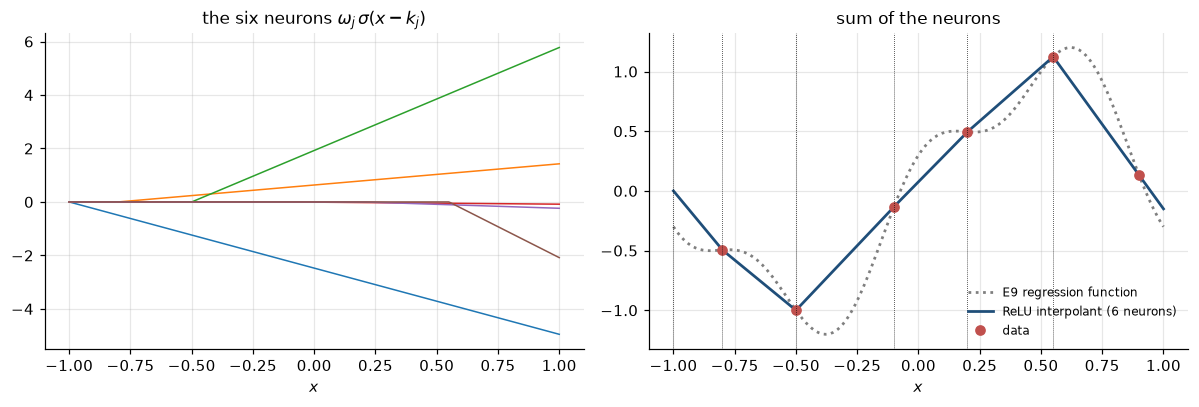

In [2]:
x_small = np.array([-0.8, -0.5, -0.1, 0.2, 0.55, 0.9])
y_small = target_E9(x_small)
knots_small, w_small = relu_interpolation_1d(x_small, y_small, left_knot=-1.0)
f_small = lambda t: relu(np.subtract.outer(t, knots_small)) @ w_small
print("knots:", knots_small, "\nouter weights:", w_small)
print(f"number of neurons: {len(w_small)} for N = {len(x_small)} points;  max |f(x_i) - y_i| = {np.abs(f_small(x_small) - y_small).max():.1e}")

grid = np.linspace(-1, 1, 400)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
for k, w in zip(knots_small, w_small):
    ax1.plot(grid, w * relu(grid - k), lw=1)
ax1.set_title(r"the six neurons $\omega_j\,\sigma(x-k_j)$"); ax1.set_xlabel("$x$")
ax2.plot(grid, target_E9(grid), color=COLORS["reference"], ls=":", label="E9 regression function")
ax2.plot(grid, f_small(grid), color=COLORS["state"], label="ReLU interpolant (6 neurons)")
ax2.plot(x_small, y_small, "o", color=COLORS["control"], label="data")
for k in knots_small:
    ax2.axvline(k, color="black", lw=0.5, ls=":")
ax2.set_xlabel("$x$"); ax2.legend(fontsize=8); ax2.set_title("sum of the neurons")
plt.tight_layout(); plt.show()

**Figure 1.** The constructive 1-D representation with $N=6$ points of the E9 regression function. *Left:* the six weighted neurons $\omega_j\sigma(x-k_j)$; the first knot is $k_1=-1$, the others are the first five data points. *Right:* their sum, the data and the knots (dotted).

*Interpretation (answer to the prediction).* Each neuron is a ramp that starts at its knot; their sum is the piecewise-linear interpolant through the six points, exact at every node (printed error at rounding level), with $N=6$ neurons and no free constant. Between nodes the network joins the data by straight segments, and to the left of $x_1$ it is a single ramp: exact representation of finite data says nothing about the function elsewhere.

## 3. Nonconvex in the inner parameters, convex in the outer weights
`CORE`

Training *all* parameters $\Theta$ is a nonconvex problem: notebook 09 (§7) gave an explicit Jensen counterexample, and even the set of exact interpolants $\{\Theta:\ f(x_i,\Theta)=y_i\ \forall i\}$ is nonconvex (p. 346). The source of the nonconvexity is the product $\omega_j\,\sigma(\langle a_j,x\rangle+b_j)$.

Now **fix the inner parameters** on a finite dictionary $(a_j,b_j)_{j=1}^P$, and write $F_{ij}=\sigma(\langle a_j,x_i\rangle+b_j)$. The predictions on the data are $F\omega$, **linear** in $\omega$. Any convex loss of $F\omega-y$, plus any convex penalty on $\omega$, is then a convex function of $\omega$, and exact interpolation is the linear constraint $F\omega=y$. This is the slides' Scheme 1 (p. 349): discretize the parameter set and solve a convex problem.

Two cautions belong to this step.

- **A global optimum on the dictionary is not a global optimum over all networks.** The convex problem only searches among networks whose neurons belong to the dictionary. Its optimal value is at least the value over all parameters in the continuous set, and in general larger.
- **The dictionary must allow what is asked.** Exact interpolation of arbitrary labels needs $\operatorname{rank}F=N$. An arbitrary grid can fail this, for instance if no neuron is active at some data point. In the laboratory we check the rank, and report infeasibility if it occurs.

## 4. Sparse problems and linear programs
`CORE`

The number of active neurons is $\|\omega\|_{\ell^0}$, which is nonconvex; the slides replace it by $\|\omega\|_{\ell^1}$, as in compressed sensing, under the principle that sparsity mitigates overfitting (p. 344). With a compact parameter set $\Omega\subset\mathbb R^{d+1}$, the three sparse problems are (p. 345)
$$
(P_0)\quad\inf_\Theta\|\omega\|_{\ell^1}\ \text{ s.t. } f(x_i,\Theta)=y_i\ \forall i;\qquad
(P_\varepsilon)\quad\inf_\Theta\|\omega\|_{\ell^1}\ \text{ s.t. } |f(x_i,\Theta)-y_i|\le\varepsilon\ \forall i;
$$
$$
(P^{\rm reg}_\lambda)\quad\inf_\Theta\ \|\omega\|_{\ell^1}+\frac{\lambda}{N}\sum_{i=1}^N\ell\big(f(x_i,\Theta)-y_i\big).
$$
**Read the convention carefully.** $\lambda$ multiplies the *loss*: a large $\lambda$ gives *more* weight to the fit and less to sparsity, and $\lambda\to\infty$ approaches interpolation (p. 349). It is not the problem "loss $+\lambda\|\omega\|_1$", where a large $\lambda$ means strong regularization.

**As linear programs, on a fixed dictionary** *(the formulation is a pedagogical addition)*. Write $\omega=\omega^+-\omega^-$ with $\omega^\pm\ge0$, so that $\|\omega\|_1=\mathbf 1^\top(\omega^++\omega^-)$ at an optimum.

- $P_0$ becomes: minimize $\mathbf 1^\top(\omega^++\omega^-)$ subject to $F(\omega^+-\omega^-)=y$, $\omega^\pm\ge0$.
- For $P^{\rm reg}_\lambda$ we **choose the absolute loss** $\ell(r)=|r|$ and add variables $t_i\ge|F\omega-y|_i$: minimize $\mathbf 1^\top(\omega^++\omega^-)+\frac\lambda N\mathbf 1^\top t$ subject to $-t\le F(\omega^+-\omega^-)-y\le t$. This choice is pedagogical: the squared loss with an $\ell^1$ penalty is also convex, but it is not a linear program.

**Which sparsity statements hold?** $P_0$ on a dictionary is a linear program in standard form with $N$ equality constraints. A *basic* (vertex) feasible solution has at most $N$ nonzero variables, and at an optimum $\omega_j^+$ and $\omega_j^-$ are not both positive, so **a vertex solution of $P_0$ uses at most $N$ neurons.** The dual simplex method returns such a vertex; an interior-point method may not. Degeneracy can give fewer than $N$. We count the support with a relative tolerance $10^{-9}$, and we make **no** such claim for the regularized problem, whose vertices are counted against $2N$ inequality constraints.

> **Predict.** On the 36 E9 training samples, how many neurons will $P_0$ use, and how will the number of active neurons of $P^{\rm reg}_\lambda$ change as $\lambda$ grows?

## 5. Laboratory: sparse shallow networks on E9
`CORE`

**Protocol** (`reports/protocol_12_16.md`, section 12, frozen before the final data were generated). E9 is the regression data of notebooks 09–11: training split (36 samples) and validation split (12). The E9 test split has been exposed since notebook 09 and is not used.

- **Dictionary, built from training inputs only:** ReLU neurons $\sigma(\pm(x-k))$ with knots $k$ at the 36 training inputs and at 25 equally spaced points of $[-1.2,1.2]$, for 122 neurons. The knots at the training inputs make exact interpolation possible; the rank is checked.
- **Procedures:** $P_0$ (exact interpolation of the training data) and $P^{\rm reg}_\lambda$ with absolute loss for $\lambda\in\{1,3,10,30,100,300,1000,3000,10000\}$.
- **Selection:** $\lambda$ with the smallest validation mean absolute error (ties to the smaller $\lambda$).
- **Final evaluation:** 500 new samples from the E9 law, drawn from the reserved stream, once, for $P_0$ and for the selected $P^{\rm reg}_\lambda$, reported side by side.

dictionary: 122 neurons;  rank of the 36 x 122 feature matrix = 36 (exact interpolation needs 36)
P0: ||omega||_1 = 998.6,  active neurons 36 (vertex bound N = 36),  max interpolation error 3.6e-14
 lambda   active neurons   training MAE   validation MAE   ||omega||_1
      1                0          0.596            0.840         0.00
      3                2          0.537            0.770         0.17
     10                2          0.371            0.626         1.11
     30                4          0.343            0.597         1.81
    100                6          0.233            0.416         8.02
    300               10          0.192            0.334        15.42
   1000               14          0.160            0.390        33.88
   3000               23          0.096            0.440       174.31
  10000               32          0.017            0.417       538.87
selected lambda (validation): 300   P0 validation MAE: 0.437


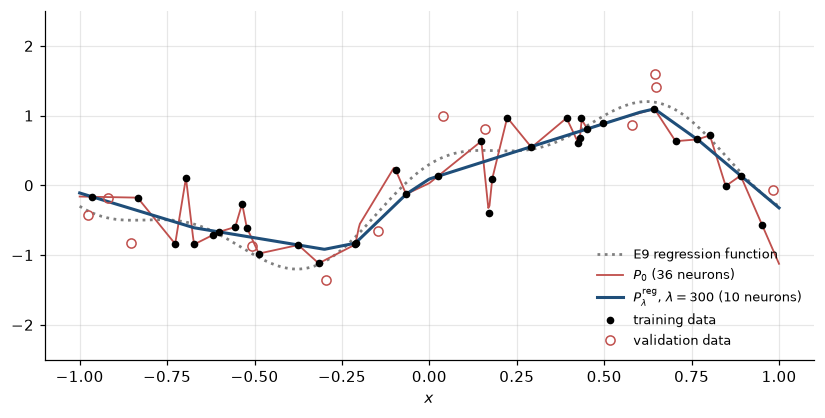

In [3]:
x_tr, y_tr, x_val, y_val = x9[train9], y9[train9], x9[val9], y9[val9]
knots = np.unique(np.concatenate([x_tr, np.linspace(-1.2, 1.2, 25)]))
a_dict = np.concatenate([np.ones_like(knots), -np.ones_like(knots)])      # neurons relu(+(x - k)) and relu(-(x - k))
b_dict = np.concatenate([-knots, knots])
features = lambda x: relu_features(x, a_dict, b_dict)
F_tr, F_val = features(x_tr), features(x_val)
print(f"dictionary: {F_tr.shape[1]} neurons;  rank of the {F_tr.shape[0]} x {F_tr.shape[1]} feature matrix = "
      f"{np.linalg.matrix_rank(F_tr)} (exact interpolation needs {len(y_tr)})")

omega_P0, dual_P0, value_P0 = l1_exact_lp(F_tr, y_tr)                    # vertex solution (dual simplex)
support_P0 = support(omega_P0)
print(f"P0: ||omega||_1 = {value_P0:.1f},  active neurons {len(support_P0)} (vertex bound N = {len(y_tr)}),  "
      f"max interpolation error {np.abs(F_tr @ omega_P0 - y_tr).max():.1e}")

lam_grid = [1, 3, 10, 30, 100, 300, 1000, 3000, 10000]


def select_lambda(F_tr, y_tr, F_val, y_val, lam_grid):
    # P^reg_lambda (absolute loss) for every lambda on TRAINING data; selection on VALIDATION mean absolute error.
    omegas = {lam: l1_regression_lp(F_tr, y_tr, lam)[0] for lam in lam_grid}
    val_mae = {lam: float(np.mean(np.abs(F_val @ om - y_val))) for lam, om in omegas.items()}
    best = min(lam_grid, key=lambda lam: (val_mae[lam], lam))
    return best, omegas, val_mae


selected_lam, omegas, val_mae = select_lambda(F_tr, y_tr, F_val, y_val, lam_grid)
print(" lambda   active neurons   training MAE   validation MAE   ||omega||_1")
for lam in lam_grid:
    om = omegas[lam]
    print(f"{lam:7d}   {len(support(om)):14d}   {np.mean(np.abs(F_tr @ om - y_tr)):12.3f}   {val_mae[lam]:14.3f}   {np.abs(om).sum():10.2f}")
print("selected lambda (validation):", selected_lam, f"  P0 validation MAE: {np.mean(np.abs(F_val @ omega_P0 - y_val)):.3f}")

grid = np.linspace(-1, 1, 600)
fig, ax = plt.subplots(figsize=(7.6, 3.9))
ax.plot(grid, target_E9(grid), color=COLORS["reference"], ls=":", label="E9 regression function")
ax.plot(grid, features(grid) @ omega_P0, color=COLORS["control"], lw=1.2, label=f"$P_0$ ({len(support_P0)} neurons)")
ax.plot(grid, features(grid) @ omegas[selected_lam], color=COLORS["state"], lw=2,
        label=rf"$P^{{\rm reg}}_\lambda$, $\lambda={selected_lam}$ ({len(support(omegas[selected_lam]))} neurons)")
ax.plot(x_tr, y_tr, "o", color="black", ms=4, label="training data")
ax.plot(x_val, y_val, "o", mfc="none", color=COLORS["control"], ms=6, label="validation data")
ax.set_ylim(-2.5, 2.5); ax.set_xlabel("$x$"); ax.legend(fontsize=8.5, loc="lower right")
plt.tight_layout(); plt.show()

**Figure 2.** Sparse shallow ReLU networks on the E9 training data (dictionary of 122 neurons): the exact-interpolation solution of $P_0$ and the regularized solution $P^{\rm reg}_\lambda$ (absolute loss) at the $\lambda$ chosen on the validation set, with training and validation data. Both curves are piecewise linear, with kinks at their active knots.

*Interpretation (answer to the prediction).* $P_0$ uses as many neurons as the printed count, at most $N=36$ as the vertex argument guarantees, and interpolates every training point, noise included: its $\ell^1$ norm is large, because passing through closely spaced noisy points needs large slopes. The regularized solution uses far fewer neurons and follows the smooth trend, at the price of a training error. On E9, interpolating the noisy labels gave a larger validation error than the regularized fit (see the table printed by the cell). Exact interpolation does not, by itself, prove poor prediction, but here it did not pay. Sparsity, by itself, is not a guarantee of a good model either.

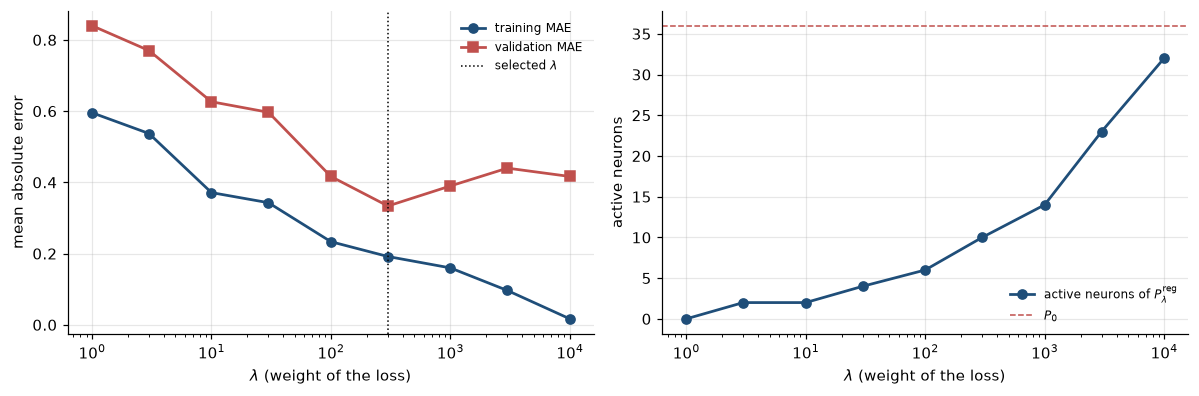

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.7))
ax1.semilogx(lam_grid, [np.mean(np.abs(F_tr @ omegas[l] - y_tr)) for l in lam_grid], "o-", color=COLORS["state"], label="training MAE")
ax1.semilogx(lam_grid, [val_mae[l] for l in lam_grid], "s-", color=COLORS["control"], label="validation MAE")
ax1.axvline(selected_lam, color="black", ls=":", lw=1, label="selected $\\lambda$")
ax1.set_xlabel(r"$\lambda$ (weight of the loss)"); ax1.set_ylabel("mean absolute error"); ax1.legend(fontsize=8)
ax2.semilogx(lam_grid, [len(support(omegas[l])) for l in lam_grid], "o-", color=COLORS["state"], label=r"active neurons of $P^{\rm reg}_\lambda$")
ax2.axhline(len(support_P0), color=COLORS["control"], ls="--", lw=1, label=r"$P_0$")
ax2.set_xlabel(r"$\lambda$ (weight of the loss)"); ax2.set_ylabel("active neurons"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Figure 3.** The path of $P^{\rm reg}_\lambda$ (absolute loss) on E9. *Left:* training and validation mean absolute errors against $\lambda$, with the selected value. *Right:* the number of active neurons, compared with $P_0$.

*Interpretation (answer to the prediction).* In the slides' convention a larger $\lambda$ gives more weight to the fit: the training error decreases. This is a general fact for optimal solutions: increasing $\lambda$ can never increase the optimal loss term, nor decrease the optimal $\|\omega\|_1$ (compare the objectives of two optimal solutions, as in Exercise 2). The number of active neurons grows **in this table**, from $0$ for small $\lambda$ (where $\omega=0$ is optimal) towards the interpolation regime. That growth is an observation here, not a guaranteed monotonicity. The validation error is smallest at an intermediate value, which is selected. Validation, not sparsity alone and not the training error, decides; and the final evaluation below reports the two procedures on new data.

In [5]:
# Final evaluation, as frozen in reports/protocol_12_16.md (section 12): 500 new E9 samples from the reserved stream,
# evaluated once for each procedure. No choice depends on these numbers.
x_eval, y_eval = regression_E9(streams["eval"], n=500)
F_eval = features(x_eval)
final12 = {}
for name, om in (("P0 (exact interpolation)", omega_P0), (f"P_reg, lambda = {selected_lam}", omegas[selected_lam])):
    r = F_eval @ om - y_eval
    final12[name] = {"MAE": float(np.mean(np.abs(r))), "MSE": float(np.mean(r**2))}
    print(f"{name:28s} final MAE {final12[name]['MAE']:.3f}   final MSE {final12[name]['MSE']:.3f}")
protocol12 = {"stream keys": stream_keys, "train indices": train9, "validation indices": val9,
              "selected lambda": selected_lam, "final evaluation": final12}

P0 (exact interpolation)     final MAE 0.323   final MSE 0.164
P_reg, lambda = 300          final MAE 0.289   final MSE 0.125


## 6. Control ↔ ML
`CORE`

- **A neuron is the vector field of a neural ODE.** **DIRECT CONNECTION** (p. 327). The slides write the neural ODE $x'=w(t)\sigma(a(t)\cdot x+b(t))$, its Euler scheme (a residual network) and the shallow network $\sum_jw_j\sigma(a_j\cdot x+b_j)$ side by side. A neuron of this notebook is the right-hand side of the dynamics of [notebook 13](13_resnets_neural_odes.ipynb).
- **$\ell^1$ on the weights, $L^\infty$ on the dual.** **MATHEMATICAL ANALOGY.** The dual of $P_0$ (DEEPER LOOK §8) bounds the correlation of every neuron with a dual vector by $1$, and the active neurons are those that reach the bound. Notebook 04 met the same pairing: the bang-bang control minimized an $L^\infty$ norm through an $L^1$-type dual functional. Similar structure, different spaces.
- **Choosing the regularization on validation data.** **DIRECT CONNECTION** with notebook 09: $\lambda$ plays the role of the polynomial degree.

## 7. Common misconceptions
`CORE`

**"The LP gives the best shallow network."** It gives the best network *among those whose neurons lie in the dictionary*. Refining the dictionary changes the answer; the continuous problem is a different one (§3, §9).

**"Every solver returns at most $N$ neurons."** The bound holds for vertex solutions of $P_0$; another solver may return a non-vertex optimum, and no such bound was claimed for $P^{\rm reg}_\lambda$ (§4).

**"A large $\lambda$ means strong regularization."** Not in the convention of p. 345, where $\lambda$ multiplies the loss (§4, Figure 3).

**"With $N$ neurons any data can be fitted."** Only if the inputs are distinct (§2); and fitting noisy labels exactly can generalize badly: on E9 it did worse on validation than the regularized fit (Figure 2), although interpolation alone does not prove poor prediction.

## 8. The dual of $P_0$ and its $L^\infty$ reading
`DEEPER LOOK`

The linear program $P_0$ on a dictionary, $\min\|\omega\|_1$ subject to $F\omega=y$, has the dual
$$
\max_{c\in\mathbb R^N}\ y^\top c\qquad\text{subject to}\qquad|F^\top c|_\infty\le1,\ \text{ i.e. }\ \Big|\sum_ic_i\,\sigma(\langle a_j,x_i\rangle+b_j)\Big|\le1\ \text{ for every neuron }j.
$$
*(Weak duality: for feasible $\omega$ and $c$, $y^\top c=\omega^\top F^\top c\le\|\omega\|_1|F^\top c|_\infty\le\|\omega\|_1$; strong duality holds for feasible linear programs.)* The dual vector $c$ assigns a weight to each data point. Every neuron's correlation with these weights is at most $1$ in absolute value, and **complementary slackness** says that a neuron can be active only if its correlation equals $\pm1$, with the sign of its weight. Choosing neurons is therefore deciding which correlations saturate, a discrete analogue of the switching structure of bang-bang controls (notebook 04).

The cell below takes the multipliers returned by the solver for the laboratory problem and checks strong duality, dual feasibility and complementary slackness.

primal value 998.592254, dual value y.c = 998.592254;  max |F^T c| = 1.0000000000
active neurons with |correlation| = 1 (to 1e-8): 36 of 36;  sign agreement: True
sum_i c_i = -3.1e-13,  sum_i c_i x_i = -1.3e-12  (their combination is the gap between the two orientations)


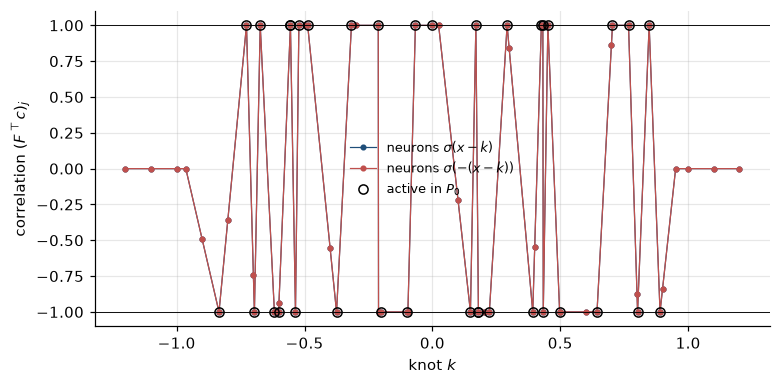

In [6]:
corr = F_tr.T @ dual_P0
print(f"primal value {value_P0:.6f}, dual value y.c = {y_tr @ dual_P0:.6f};  max |F^T c| = {np.abs(corr).max():.10f}")
print(f"active neurons with |correlation| = 1 (to 1e-8): {np.sum(np.abs(np.abs(corr[support_P0]) - 1) < 1e-8)} of {len(support_P0)};  "
      f"sign agreement: {bool(np.all(np.sign(corr[support_P0]) == np.sign(omega_P0[support_P0])))}")
print(f"sum_i c_i = {dual_P0.sum():.1e},  sum_i c_i x_i = {dual_P0 @ x_tr:.1e}  (their combination is the gap between the two orientations)")
n_k = len(knots)
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(knots, corr[:n_k], ".-", color=COLORS["state"], lw=0.8, label=r"neurons $\sigma(x-k)$")
ax.plot(knots, corr[n_k:], ".-", color=COLORS["control"], lw=0.8, label=r"neurons $\sigma(-(x-k))$")
ax.plot(np.concatenate([knots, knots])[support_P0], corr[support_P0], "o", mfc="none", color="black", label="active in $P_0$")
ax.axhline(1, color="black", lw=0.6); ax.axhline(-1, color="black", lw=0.6)
ax.set_xlabel("knot $k$"); ax.set_ylabel(r"correlation $(F^\top c)_j$"); ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

**Figure 4.** The dual certificate of $P_0$ on the E9 laboratory: the correlation $(F^\top c)_j$ of every neuron of the dictionary with the dual vector returned by the solver, plotted against the knot, for the two orientations of the ReLU; circles mark the neurons active in the primal solution.

*Interpretation.* All correlations lie in $[-1,1]$ (dual feasibility), and every active neuron sits exactly on $\pm1$ with the sign of its weight (complementary slackness), as printed; the primal and dual values coincide. The two orientations give the same curve: since $\sigma(z)-\sigma(-z)=z$, their correlations differ by $\sum_ic_i(x_i-k)$, an affine function of $k$, and for this dual solution the printed sums $\sum_ic_i$ and $\sum_ic_ix_i$ vanish to rounding. That is an observation about this solution, not something we have proved in general. The certificate proves optimality *on this dictionary*, nothing more.

## 9. Mean-field relaxation and the absence of a relaxation gap
`RESEARCH WINDOW`

Replacing the finite sum by an integral against a signed measure, $\int_\Omega\sigma(\langle a,x\rangle+b)\,d\mu(a,b)$, makes the network **linear in $\mu$**, and the cost $\|\omega\|_{\ell^1}$ becomes the total variation $\|\mu\|_{\rm TV}$ (pp. 346–347). The relaxed problems $(PR_0)$, $(PR_\varepsilon)$, $(PR^{\rm reg}_\lambda)$ are convex.

> **Theorem (Liu–Zuazua 2024; p. 348), transcribed.** *Assumptions:* $\sigma$ is continuous, with $\sigma(z)=0$ for $z\le0$ and $\sigma(z)>0$ for $z>0$; $\Omega$ is compact and contains a ball centred at $0$; $P\ge N$. *Conclusion:* the values of $P_0$, $P_\varepsilon$, $P^{\rm reg}_\lambda$ equal those of their relaxations, and the extreme points of the relaxed solution sets are sums of $N$ Dirac masses, $\mu^*=\sum_{j=1}^N\omega_j^*\delta_{(a_j^*,b_j^*)}$.

The ReLU satisfies the assumption on $\sigma$. **This equality concerns the continuous parameter set $\Omega$.** Our dictionary is a finite subset of parameters, which is not such an $\Omega$ (it contains no ball), so the theorem does not say that the discretized problem has the same value; refining the dictionary approaches the continuous problem only under further arguments not given here. The slides also suggest, for heavily overlapping data, choosing $\lambda\sim N^{1/d}$ in $P^{\rm reg}_\lambda$ (p. 349); this is a recommendation in that context, not a universal law, and in this notebook $\lambda$ was chosen on validation data. Scheme 2 (SGD on over-parametrized networks with sparsification, Chizat–Bach 2018) avoids the curse of dimension of grids but lacks global guarantees (p. 349).

## 10. What you should remember
`CORE`

1. Approximation of functions, exact representation of finite data and regression are different objectives.
2. With distinct inputs, $P\ge N$ and a non-polynomial activation, one hidden layer interpolates any labels; in 1-D, $N$ ReLU neurons do it by a triangular system, with no free bias.
3. Fixing the inner parameters makes the network linear in $\omega$: interpolation and sparse regression become convex, and with an $\ell^1$ cost and absolute loss, linear programs.
4. A global optimum on a dictionary is not a global optimum over all networks.
5. In the slides' convention, $\lambda$ multiplies the loss: for optimal solutions, a larger $\lambda$ never increases the loss term nor decreases $\|\omega\|_1$. The number of active neurons grew with $\lambda$ in our table, which is an observation, not a theorem.
6. A vertex solution of $P_0$ has at most $N$ active neurons; no such bound is claimed for other solutions or for $P^{\rm reg}_\lambda$.

## 11. Exercises

★ conceptual · ★★ mathematical · ★★★ computational. `FIRST PASS` exercises are the minimum route; `STANDARD` ones consolidate the notebook; `ADVANCED` ones are optional. Reference solutions are kept in a separate instructor notebook. Try first.

**Exercise 1 ★ ($\ell^0$ or $\ell^1$?)** · `FIRST PASS`. (a) Show that $\omega\mapsto\|\omega\|_{\ell^0}$ (the number of nonzero entries) is not convex on $\mathbb R^2$. (b) Why is $\|\omega\|_{\ell^1}$ a natural convex replacement? (c) Give a $2\times3$ system $F\omega=y$ whose minimum-$\ell^1$ solution is not the sparsest solution. *Hint:* take columns of very different lengths.

**Exercise 2 ★★ (the two limits of $P^{\rm reg}_\lambda$)** · `FIRST PASS`. For the absolute-loss problem $\min_\omega\|\omega\|_1+\frac\lambda N\|F\omega-y\|_1$ on a fixed dictionary: (a) show that $\omega=0$ is optimal when $\lambda\max_j\|F_{:,j}\|_1\le N$. (b) Show that when $\operatorname{rank}F=N$ and $\lambda$ is large enough, every optimal solution interpolates. (c) Check both statements numerically on the laboratory dictionary.

**Exercise 3 ★★ (the 1-D construction)** · `STANDARD`. (a) Prove that the system of §2 is lower triangular with positive diagonal, hence uniquely solvable. (b) Show that if $y_1=0$ the first neuron can be dropped, and give an example where fewer than $N$ neurons interpolate. (c) Explain why no construction can interpolate the data $(0,0)$, $(0,1)$, whatever the width, and how this is reflected in the hypotheses of §2.

**Exercise 4 ★★ (duality and complementary slackness)** · `STANDARD`. (a) Derive the dual of $P_0$ on a dictionary from the LP in $(\omega^+,\omega^-)$. (b) Prove that at optimal $\omega$ and $c$, $\omega_j\ne0$ implies $(F^\top c)_j=\operatorname{sgn}(\omega_j)$. (c) What does a neuron with $|(F^\top c)_j|<1$ tell you about the effect of adding it with a small weight?

**Exercise 5 ★★★ (the approximate problem $P_\varepsilon$)** · `ADVANCED`. Write $P_\varepsilon$ on the laboratory dictionary as a linear program, solve it for $\varepsilon\in\{0.05,0.1,0.2,0.3,0.5\}$ on the training data, and report the number of active neurons and the **validation** mean absolute error for each $\varepsilon$. Which $\varepsilon$ would you choose, on validation data only? Do not use the final evaluation data, which were reserved for the two procedures of §5.

In [7]:
# TODO: student exercise (Exercise 5)
# Variables (omega+, omega-) >= 0; constraints -eps <= F_tr (omega+ - omega-) - y_tr <= eps; objective 1'(omega+ + omega-).

def l1_eps_lp(F, y, eps):
    ...  # your code here
    return None

**Exercise 6 ★★★ (the curse of dimension of Scheme 1)** · `ADVANCED`. For inputs in $\mathbb R^d$, normalize neurons by $|(a,b)|=1$ and discretize the unit sphere of $\mathbb R^{d+1}$ with spacing about $h$. (a) Estimate the number of dictionary neurons as a function of $d$ and $h$. (b) Tabulate it for $h=0.1$ and $d=1,\dots,6$, and compare with the memory of a dense $N\times P$ matrix for $N=1000$. (c) Relate your table to the two schemes of p. 349.

## Where are we going?
`CORE`

A neuron $w\sigma(a\cdot x+b)$ is exactly the vector field of the neural ODEs on p. 327. [Notebook 13](13_resnets_neural_odes.ipynb) stacks such fields in time: a residual network becomes a controlled dynamical system, its parameters become controls, and its training is differentiated with the adjoint method of notebook 07.

## Source map
`CORE`

All page numbers are PDF pages of `CML_slides_20250520.pdf`; the machine-readable version is `source_map.csv`.

| Section | PDF pages | Content in the slides |
|---|---|---|
| §1 Objectives | 342, 343 | $f(x,\Theta)$; exact / approximate representation, regression; shallow network |
| §2 Representation | 343 | Finite-sample representation (Pinkus); Liu–Zuazua extension |
| §3 Convexity | 346, 349 | Nonconvex interpolation set; Scheme 1 (discretize + simplex) |
| §4 Sparse problems | 344, 345 | Sparsity and overfitting; $\ell^0\to\ell^1$; $P_0$, $P_\varepsilon$, $P^{\rm reg}_\lambda$ |
| §6 Control ↔ ML | 327 | NODE, ResNet and shallow network side by side |
| §8 Dual (DEEPER LOOK) | 173 | Linear programming (via notebook 06) |
| §9 Relaxation (RESEARCH WINDOW) | 346–349 | Mean-field networks; relaxed problems; no-gap theorem; numerical schemes; $\lambda\sim N^{1/d}$ |

The source-map rows also record the pedagogical additions (the distinction from function approximation, the constructive 1-D proof and Figure 1, the LP formulations with absolute loss, the vertex sparsity argument, the E9 laboratory with its frozen protocol and Figures 2–3, the dual certificate and Figure 4) and the remarks (continuity in Pinkus's setting, not printed on p. 343; the theorem of p. 348 concerns a continuous $\Omega$, not the finite dictionary).